In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import cartopy.feature as cfeature
import os
from sklearn.linear_model import LinearRegression
from scipy.stats import gaussian_kde
import xesmf as xe

In [18]:
home_path = os.path.expanduser("~")

path = '/DataFiles'
path2 = '/Library/Mobile Documents/com~apple~CloudDocs/Documents/Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium'

era5 = xr.open_dataset(home_path + path + "/ae3baa6a74f0aa315dc3de6f83298f0e.nc")
racmo = xr.open_dataset(home_path + path + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc")
mask = xr.open_dataset(home_path + path + "/TotIS_RACMO_ANT27_IMBIE2.nc")

folder = home_path + path 

In [31]:
ais_racmo_base = np.load(folder + "/RACMO_AIS_ACCUM.npy")
wais_racmo_base = np.load(folder + "/RACMO_WAIS_ACCUM.npy")
eais_racmo_base = np.load(folder + "/RACMO_EAIS_ACCUM.npy")
ap_racmo_base = np.load(folder + "/RACMO_AP_ACCUM.npy")

ais_era5_base = np.load(folder + "/ERA5_AIS_ACCUM.npy")
wais_era5_base = np.load(folder + "/ERA5_WAIS_ACCUM.npy")
eais_era5_base = np.load(folder + "/ERA5_EAIS_ACCUM.npy")
ap_era5_base = np.load(folder + "/ERA5_AP_ACCUM.npy")

ais_accum_accum = np.load(folder + "/ACCUM_AIS_ACCUM.npy")
wais_accum_accum = np.load(folder + "/ACCUM_WAIS_ACCUM.npy")
eais_accum_accum = np.load(folder + "/ACCUM_EAIS_ACCUM.npy")
ap_accum_accum = np.load(folder + "/ACCUM_AP_ACCUM.npy")

ais_accum_double = np.load(folder + "/ACCUM_AIS_DOUBLE.npy")
wais_accum_double = np.load(folder + "/ACCUM_WAIS_DOUBLE.npy")
eais_accum_double = np.load(folder + "/ACCUM_EAIS_DOUBLE.npy")
ap_accum_double = np.load(folder + "/ACCUM_AP_DOUBLE.npy")



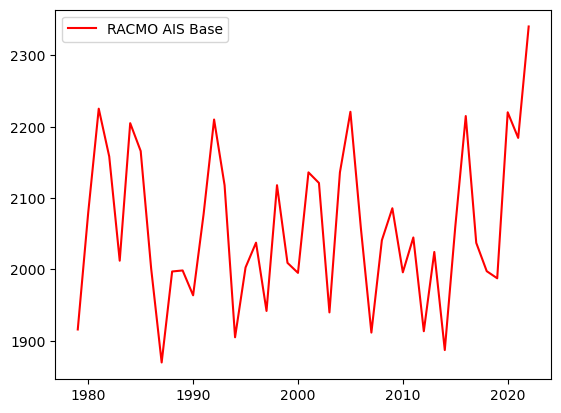

In [22]:
satYears = np.arange(1979, 2023)  # 1979-2022
reconYears = np.arange(1801, 2001)
midYears = np.arange(1979, 2001)

#plt.plot(satYears, ais_era5_base, label='ERA5 AIS Base', color='blue')
plt.plot(satYears, ais_racmo_base, label='RACMO AIS Base', color='red')
plt.legend()

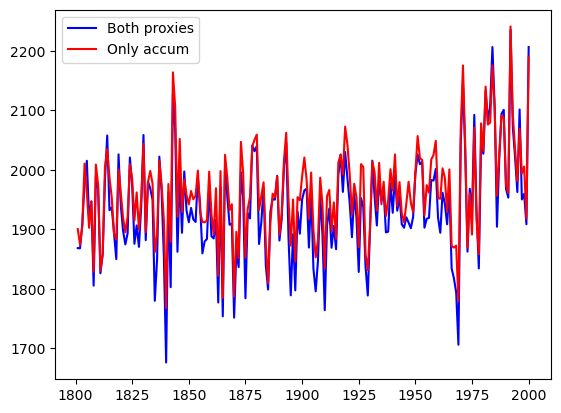

In [23]:
plt.plot(reconYears, ais_accum_double, label='Both proxies', color='blue')
plt.plot(reconYears, ais_accum_accum, label='Only accum', color='red')
plt.legend()

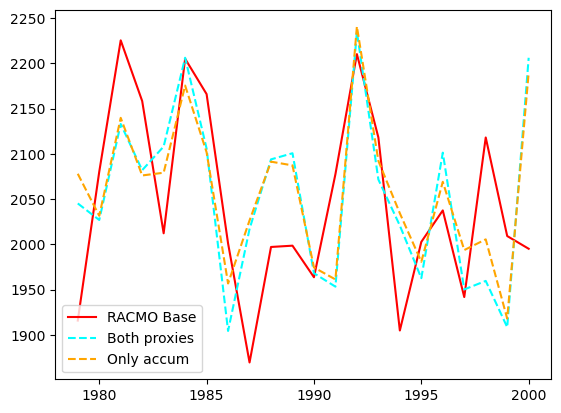

In [25]:

plt.plot(midYears, ais_racmo_base[:22], label='RACMO Base', color='red')
plt.plot(midYears, ais_accum_double[178:200], label='Both proxies', color='cyan', linestyle='--')
plt.plot(midYears, ais_accum_accum[178:200], label='Only accum', color='orange', linestyle='--')
plt.legend()

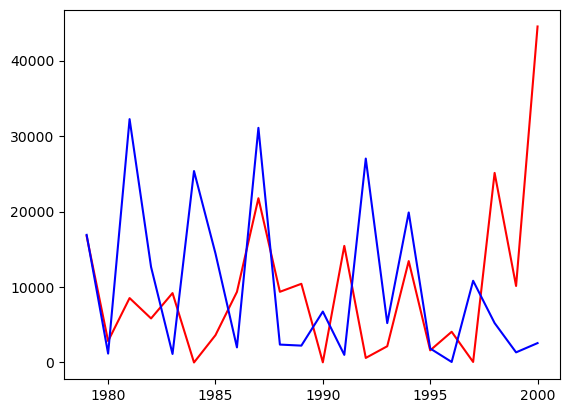

In [49]:
plt.plot(midYears, (ais_accum_double[178:200] - ais_racmo_base[:22]) ** 2, color='red')
plt.plot(midYears, (ais_racmo_base[:22] - np.mean(ais_racmo_base[:22])) ** 2, color='blue')

In [ ]:
print("AIS")
print("Both proxies = " + np.corrcoef(ais_era5_base[:22], ais_accum_double[178:200])[0,1].astype(str))
print("Only accum = " + np.corrcoef(ais_era5_base[:22], ais_accum_accum[178:200])[0,1].astype(str))

num_double = np.sum((ais_accum_double[178:200] - ais_era5_base[:22])**2)
den_double = np.sum((ais_era5_base[:22] - np.mean(ais_era5_base[:22]))**2)
ce_double = 1 - (num_double / den_double)

num_accum = np.sum((ais_accum_accum[178:200] - ais_era5_base[:22])**2)
den_accum = np.sum((ais_era5_base[:22] - np.mean(ais_era5_base[:22]))**2)
ce_accum = 1 - (num_accum / den_accum)

print("CE Both proxies = " + ce_double.astype(str))
print("CE Only accum = " + ce_accum.astype(str))

AIS
Both proxies = 0.43321506088890677
Only accum = 0.4510239175818431
CE Both proxies = -0.21812396242203458
CE Only accum = -0.17224796267274511


In [52]:
print("WAIS")
print("Both proxies = " + np.corrcoef(wais_era5_base[:22], wais_accum_double[178:200])[0,1].astype(str))
print("Only accum = " + np.corrcoef(wais_era5_base[:22], wais_accum_accum[178:200])[0,1].astype(str))

num_double = np.sum((wais_accum_double[178:200] - wais_era5_base[:22])**2)
den_double = np.sum((wais_era5_base[:22] - np.mean(wais_era5_base[:22]))**2)
ce_double = 1 - (num_double / den_double)

num_accum = np.sum((wais_accum_accum[178:200] - wais_era5_base[:22])**2)
den_accum = np.sum((wais_era5_base[:22] - np.mean(wais_era5_base[:22]))**2)
ce_accum = 1 - (num_accum / den_accum)

print("CE Both proxies = " + ce_double.astype(str))
print("CE Only accum = " + ce_accum.astype(str))

WAIS
Both proxies = 0.7378820414285003
Only accum = 0.7004968512758307
CE Both proxies = -0.14098408807874496
CE Only accum = -0.1790776149336779


In [53]:
print("EAIS")
print("Both proxies = " + np.corrcoef(eais_era5_base[:22], eais_accum_double[178:200])[0,1].astype(str))
print("Only accum = " + np.corrcoef(eais_era5_base[:22], eais_accum_accum[178:200])[0,1].astype(str))

num_double = np.sum((eais_accum_double[178:200] - eais_era5_base[:22])**2)
den_double = np.sum((eais_era5_base[:22] - np.mean(eais_era5_base[:22]))**2)
ce_double = 1 - (num_double / den_double)

num_accum = np.sum((eais_accum_accum[178:200] - eais_era5_base[:22])**2)
den_accum = np.sum((eais_era5_base[:22] - np.mean(eais_era5_base[:22]))**2)
ce_accum = 1 - (num_accum / den_accum)

print("CE Both proxies = " + ce_double.astype(str))
print("CE Only accum = " + ce_accum.astype(str))

EAIS
Both proxies = 0.3031133590014423
Only accum = 0.34879871014691066
CE Both proxies = -0.9825555558014176
CE Only accum = -0.7604990332742365


In [35]:
print("AP")
print("Both proxies = " + np.corrcoef(ap_era5_base[:22], ap_accum_double[178:200])[0,1].astype(str))
print("Only accum = " + np.corrcoef(ap_era5_base[:22], ap_accum_accum[178:200])[0,1].astype(str))

AP
Both proxies = 0.7910029208864772
Only accum = 0.7457472678891105


In [36]:
ais_accum_slm = np.load(folder + "/SLM_AIS_ACCUM.npy")
wais_accum_slm = np.load(folder + "/SLM_WAIS_ACCUM.npy")
eais_accum_slm = np.load(folder + "/SLM_EAIS_ACCUM.npy")
ap_accum_slm = np.load(folder + "/SLM_AP_ACCUM.npy")

ais_double_slm = np.load(folder + "/SLM_AIS_DOUBLE.npy")
wais_double_slm = np.load(folder + "/SLM_WAIS_DOUBLE.npy")
eais_double_slm = np.load(folder + "/SLM_EAIS_DOUBLE.npy")
ap_double_slm = np.load(folder + "/SLM_AP_DOUBLE.npy")




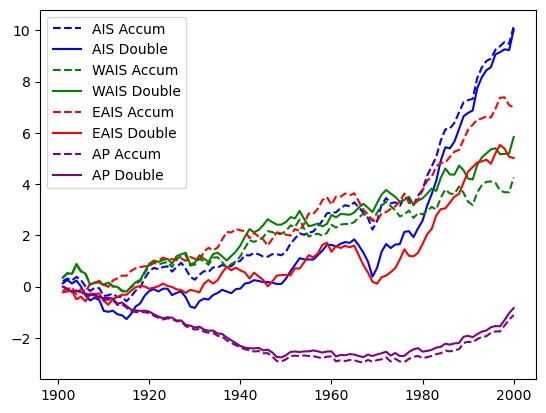

In [37]:
plt.plot(reconYears[100:], ais_accum_slm[100:], label='AIS Accum', color='blue', linestyle='--')
plt.plot(reconYears[100:], ais_double_slm[100:], label='AIS Double', color='blue')

plt.plot(reconYears[100:], wais_accum_slm[100:], label='WAIS Accum', color='green', linestyle='--')
plt.plot(reconYears[100:], wais_double_slm[100:], label='WAIS Double', color='green')

plt.plot(reconYears[100:], eais_accum_slm[100:], label='EAIS Accum', color='red', linestyle='--')
plt.plot(reconYears[100:], eais_double_slm[100:], label='EAIS Double', color='red')

plt.plot(reconYears[100:], ap_accum_slm[100:], label='AP Accum', color='purple', linestyle='--')
plt.plot(reconYears[100:], ap_double_slm[100:], label='AP Double', color='purple')

plt.legend()